In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Reload and re-clean data
# (same steps as Day 1 — we'll modularize into src/ later)
df = pd.read_csv(
    '../data/accepted_2007_to_2018Q4.csv.gz',
    # nrows=100000,
    low_memory=False
)

# Target variable
resolved = ['Fully Paid', 'Charged Off', 'Default']
df = df[df['loan_status'].isin(resolved)].copy()
df['target'] = df['loan_status'].isin(['Charged Off', 'Default']).astype(int)

# Drop leakage columns
leakage_cols = [
    'out_prncp', 'out_prncp_inv',
    'total_pymnt', 'total_pymnt_inv',
    'total_rec_prncp', 'total_rec_int',
    'total_rec_late_fee', 'recoveries',
    'collection_recovery_fee', 'last_pymnt_d',
    'last_pymnt_amnt', 'next_pymnt_d',
    'last_credit_pull_d', 'last_fico_range_high',
    'last_fico_range_low', 'debt_settlement_flag'
]
df = df.drop(columns=[c for c in leakage_cols if c in df.columns])

# Drop high missing columns
missing_pct = df.isnull().sum() / len(df) * 100
high_missing = missing_pct[missing_pct > 50].index.tolist()
df = df.drop(columns=high_missing)

print(f"✅ Data loaded: {df.shape}")
print(f"Default rate: {df['target'].mean()*100:.1f}%")

✅ Data loaded: (1345350, 79)
Default rate: 20.0%


In [22]:
# term: " 36 months" → 36
df['term'] = df['term'].str.extract('(\d+)').astype(float)

# emp_length: "10+ years" → 10, "< 1 year" → 0
df['emp_length'] = df['emp_length'].str.extract('(\d+)')
df['emp_length'] = df['emp_length'].fillna(0).astype(float)

# int_rate: already float in newer pandas, but just in case
if df['int_rate'].dtype == object:
    df['int_rate'] = df['int_rate'].str.replace('%', '').astype(float)

# revol_util: "65.3%" → 65.3
if df['revol_util'].dtype == object:
    df['revol_util'] = df['revol_util'].str.replace('%', '').astype(float)

# issue_d: "Jan-2015" → extract year and month separately
df['issue_d'] = pd.to_datetime(df['issue_d'], format='%b-%Y')
df['issue_year'] = df['issue_d'].dt.year
df['issue_month'] = df['issue_d'].dt.month

# earliest_cr_line: credit history length in years
df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'], 
                                          format='%b-%Y', errors='coerce')
df['credit_history_years'] = (df['issue_d'] - df['earliest_cr_line']).dt.days / 365

print("✅ Text columns converted")
print(df[['term', 'emp_length', 'int_rate', 'revol_util', 
          'issue_year', 'credit_history_years']].describe())

✅ Text columns converted
               term    emp_length      int_rate    revol_util    issue_year  \
count  1.345350e+06  1.345350e+06  1.345350e+06  1.344493e+06  1.345350e+06   
mean   4.179029e+01  5.697999e+00  1.323971e+01  5.180978e+01  2.014972e+03   
std    1.026838e+01  3.735894e+00  4.768782e+00  2.452110e+01  1.639698e+00   
min    3.600000e+01  0.000000e+00  5.310000e+00  0.000000e+00  2.007000e+03   
25%    3.600000e+01  2.000000e+00  9.750000e+00  3.340000e+01  2.014000e+03   
50%    3.600000e+01  6.000000e+00  1.274000e+01  5.220000e+01  2.015000e+03   
75%    3.600000e+01  1.000000e+01  1.599000e+01  7.070000e+01  2.016000e+03   
max    6.000000e+01  1.000000e+01  3.099000e+01  8.923000e+02  2.018000e+03   

       credit_history_years  
count          1.345350e+06  
mean           1.627037e+01  
std            7.511227e+00  
min            3.000000e+00  
25%            1.125205e+01  
50%            1.475890e+01  
75%            2.001370e+01  
max            8.330685

In [23]:
print("term dtype:", df['term'].dtype)
print("term sample values:", df['term'].unique()[:5])

print("\nemp_length dtype:", df['emp_length'].dtype)  
print("emp_length sample values:", df['emp_length'].unique()[:5])

print("\nint_rate dtype:", df['int_rate'].dtype)
print("revol_util dtype:", df['revol_util'].dtype)

term dtype: float64
term sample values: [36. 60.]

emp_length dtype: float64
emp_length sample values: [10.  3.  4.  6.  7.]

int_rate dtype: float64
revol_util dtype: float64


In [24]:
# issue_d: "Jan-2015" → extract year and month
df['issue_d'] = pd.to_datetime(df['issue_d'], format='%b-%Y')
df['issue_year'] = df['issue_d'].dt.year
df['issue_month'] = df['issue_d'].dt.month

# credit history length in years
df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'], 
                                          format='%b-%Y', errors='coerce')
df['credit_history_years'] = (df['issue_d'] - df['earliest_cr_line']).dt.days / 365

print("✅ Date columns converted")
print(df[['issue_year', 'issue_month', 'credit_history_years']].describe())

✅ Date columns converted
         issue_year   issue_month  credit_history_years
count  1.345350e+06  1.345350e+06          1.345350e+06
mean   2.014972e+03  6.508865e+00          1.627037e+01
std    1.639698e+00  3.449882e+00          7.511227e+00
min    2.007000e+03  1.000000e+00          3.000000e+00
25%    2.014000e+03  3.000000e+00          1.125205e+01
50%    2.015000e+03  7.000000e+00          1.475890e+01
75%    2.016000e+03  1.000000e+01          2.001370e+01
max    2.018000e+03  1.200000e+01          8.330685e+01


In [25]:
# 1. Loan to income ratio — how large is loan relative to income?
df['loan_to_income'] = df['loan_amnt'] / (df['annual_inc'] + 1)

# 2. Instalment to income ratio — monthly payment burden
df['installment_to_income'] = df['installment'] / (df['annual_inc'] / 12 + 1)

# 3. Credit utilization flag — using more than 80% of revolving credit
df['high_utilization'] = (df['revol_util'] > 80).astype(int)

# 4. Has public record — any bankruptcy or derogatory marks
df['has_pub_rec'] = (df['pub_rec'] > 0).astype(int)

# 5. Has delinquency — any missed payments in last 2 years
df['has_delinq'] = (df['delinq_2yrs'] > 0).astype(int)

# 6. Short credit history flag — less than 3 years
df['short_credit_history'] = (df['credit_history_years'] < 3).astype(int)

print("✅ New features engineered")
print("\nNew feature correlations with default:")
new_features = ['loan_to_income', 'installment_to_income', 
                'high_utilization', 'has_pub_rec', 
                'has_delinq', 'short_credit_history']
for f in new_features:
    corr = df[f].corr(df['target'])
    print(f"  {f}: {corr:.4f}")

✅ New features engineered

New feature correlations with default:
  loan_to_income: 0.0005
  installment_to_income: 0.0011
  high_utilization: 0.0285
  has_pub_rec: 0.0315
  has_delinq: 0.0182
  short_credit_history: nan


In [26]:
# Numerical features to use in model
numerical_features = [
    # Loan characteristics
    'loan_amnt', 'term', 'int_rate', 'installment',
    # Borrower financials
    'annual_inc', 'dti', 'emp_length',
    # Credit history
    'fico_range_low', 'fico_range_high', 'credit_history_years',
    'open_acc', 'total_acc', 'revol_bal', 'revol_util',
    # Derogatory marks
    'pub_rec', 'delinq_2yrs', 'inq_last_6mths',
    # Engineered features
    'loan_to_income', 'installment_to_income',
    'high_utilization', 'has_pub_rec',
    'has_delinq', 'short_credit_history',
    # Time features
    'issue_year', 'issue_month'
]

# Categorical features
categorical_features = [
    'grade', 'sub_grade', 'home_ownership',
    'verification_status', 'purpose', 'addr_state'
]

# Keep only what exists in our dataframe
numerical_features = [f for f in numerical_features if f in df.columns]
categorical_features = [f for f in categorical_features if f in df.columns]

print(f"Numerical features: {len(numerical_features)}")
print(f"Categorical features: {len(categorical_features)}")
print(f"Total features: {len(numerical_features) + len(categorical_features)}")

Numerical features: 25
Categorical features: 6
Total features: 31


In [27]:
def calculate_iv(df, feature, target, bins=10):
    """
    Calculate Information Value for a feature
    IV tells us how predictive a feature is:
    < 0.02  = useless
    0.02-0.1 = weak
    0.1-0.3  = medium  
    > 0.3    = strong
    """
    try:
        if df[feature].dtype in ['object', 'category']:
            grouped = df.groupby(feature)[target].agg(['sum', 'count'])
        else:
            df_temp = df.copy()
            df_temp['bin'] = pd.qcut(df_temp[feature], 
                                      q=bins, 
                                      duplicates='drop')
            grouped = df_temp.groupby('bin')[target].agg(['sum', 'count'])
        
        grouped.columns = ['defaults', 'total']
        grouped['non_defaults'] = grouped['total'] - grouped['defaults']
        
        total_defaults = grouped['defaults'].sum()
        total_non_defaults = grouped['non_defaults'].sum()
        
        grouped['pct_defaults'] = grouped['defaults'] / total_defaults
        grouped['pct_non_defaults'] = grouped['non_defaults'] / total_non_defaults
        
        # Avoid division by zero
        grouped = grouped[
            (grouped['pct_defaults'] > 0) & 
            (grouped['pct_non_defaults'] > 0)
        ]
        
        grouped['woe'] = np.log(
            grouped['pct_defaults'] / grouped['pct_non_defaults']
        )
        grouped['iv'] = (
            grouped['pct_defaults'] - grouped['pct_non_defaults']
        ) * grouped['woe']
        
        return grouped['iv'].sum()
    
    except Exception:
        return 0

# Calculate IV for all features
print("Calculating Information Value for all features...")
print("(This may take a minute)\n")

iv_results = {}

for feature in numerical_features + categorical_features:
    if feature in df.columns and feature != 'target':
        iv = calculate_iv(df, feature, 'target')
        iv_results[feature] = iv

# Sort by IV
iv_df = pd.DataFrame.from_dict(iv_results, orient='index', 
                                 columns=['IV'])
iv_df = iv_df.sort_values('IV', ascending=False)

# Label predictive power
def iv_label(iv):
    if iv < 0.02: return 'Useless'
    elif iv < 0.1: return 'Weak'
    elif iv < 0.3: return 'Medium'
    else: return 'Strong'

iv_df['Predictive_Power'] = iv_df['IV'].apply(iv_label)

print("Top 20 features by Information Value:")
print(iv_df.head(20).to_string())

Calculating Information Value for all features...
(This may take a minute)

Top 20 features by Information Value:
                             IV Predictive_Power
int_rate               0.450211           Strong
fico_range_high        0.122645           Medium
fico_range_low         0.122645           Medium
loan_to_income         0.119904           Medium
installment_to_income  0.096789             Weak
dti                    0.072696             Weak
loan_amnt              0.034817             Weak
issue_year             0.032873             Weak
installment            0.030250             Weak
annual_inc             0.029181             Weak
revol_util             0.025159             Weak
inq_last_6mths         0.017399          Useless
credit_history_years   0.009577          Useless
emp_length             0.006216          Useless
open_acc               0.004849          Useless
revol_bal              0.003617          Useless
delinq_2yrs            0.001907          Useless
issu

In [28]:
# Keep features with IV > 0.02 (weak or better)
useful_features = iv_df[iv_df['IV'] > 0.02].index.tolist()
print(f"Features with IV > 0.02: {len(useful_features)}")

# Final feature matrix
feature_cols = [f for f in useful_features 
                if f in df.columns and f != 'target']

df_model = df[feature_cols + ['target', 'issue_d', 
                                'grade', 'loan_amnt']].copy()

# Handle remaining missing values
for col in df_model.select_dtypes(include='number').columns:
    df_model[col] = df_model[col].fillna(df_model[col].median())

for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = df_model[col].fillna(df_model[col].mode()[0])

print(f"\n✅ Final model dataset: {df_model.shape}")
print(f"Features ready for modeling: {len(feature_cols)}")

# Save for use in next notebooks
df_model.to_csv('../data/df_model.csv', index=False)
print("✅ Saved to data/df_model.csv")

Features with IV > 0.02: 11



✅ Final model dataset: (1345350, 15)
Features ready for modeling: 11
✅ Saved to data/df_model.csv


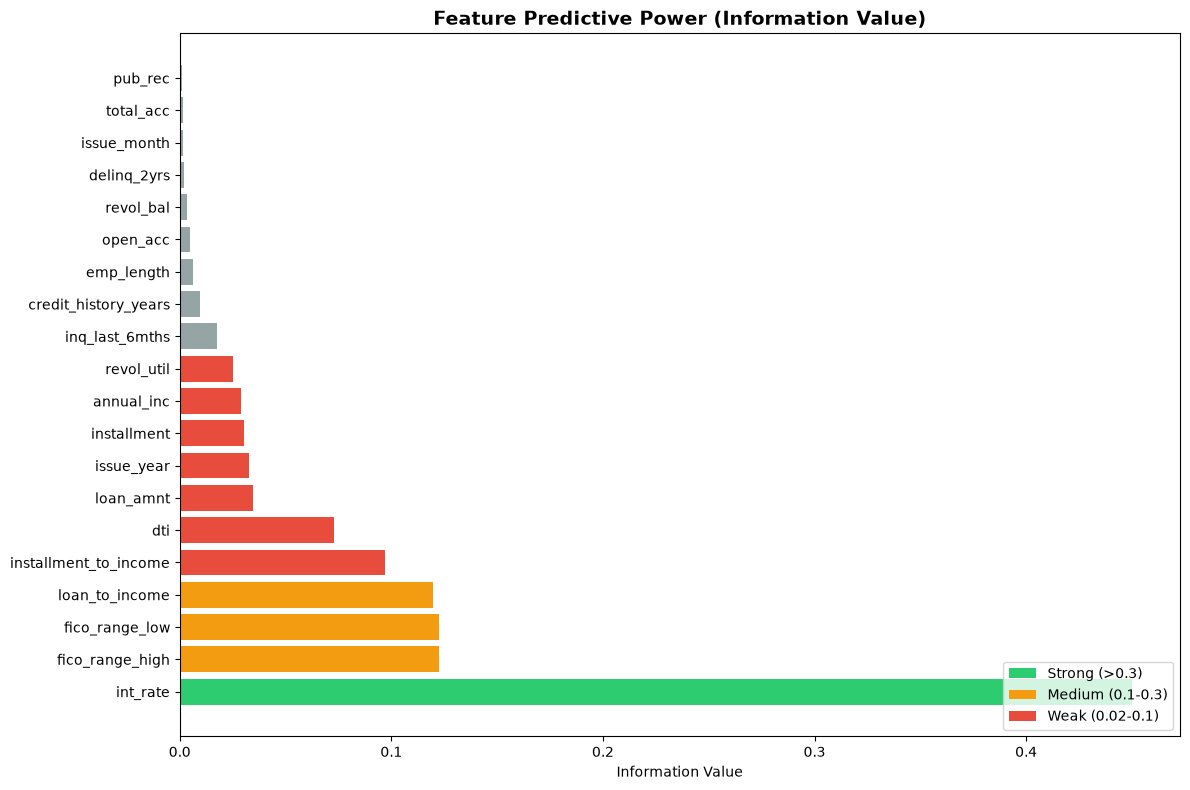


✅ Feature engineering complete
Started with 80 features → ended with 11 useful features


In [29]:
# Plot top 20 features by IV
top_features = iv_df.head(20)

colors = top_features['Predictive_Power'].map({
    'Strong': '#2ecc71',
    'Medium': '#f39c12', 
    'Weak': '#e74c3c',
    'Useless': '#95a5a6'
})

plt.figure(figsize=(12, 8))
bars = plt.barh(top_features.index, 
                top_features['IV'], 
                color=colors)
plt.xlabel('Information Value')
plt.title('Feature Predictive Power (Information Value)', 
          fontsize=14, fontweight='bold')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='Strong (>0.3)'),
    Patch(facecolor='#f39c12', label='Medium (0.1-0.3)'),
    Patch(facecolor='#e74c3c', label='Weak (0.02-0.1)'),
]
plt.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.savefig('../notebooks/images/05_information_value.png', dpi=150)
plt.show()

print("\n✅ Feature engineering complete")
print(f"Started with 80 features → ended with {len(feature_cols)} useful features")